In [1]:
# load the necessary packages
library("tidyverse")
library("lme4")
library("emmeans")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'



In [2]:
# load the data
data <- read.csv('df_ampc_vs_loss.csv')

In [3]:
data

X,v1_unit,dlgn_unit,upper_bound,ampc,loss
<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>
0,1,1_1,0.1,0.015020,0.06836
1,1,1_1,0.1,0.015350,0.06573
2,1,1_1,0.1,0.022260,0.12650
3,1,1_1,0.1,0.015320,0.07610
4,1,1_1,0.1,0.018110,0.09424
5,1,1_1,0.1,0.013630,0.07590
6,1,1_1,0.1,0.013750,0.07330
7,1,1_1,0.1,0.016880,0.06900
8,1,1_1,0.1,0.016400,0.07310


In [4]:
data$upper_bound <- as.factor(data$upper_bound)

In [5]:
model = lmer(loss ~ 1 + ampc*v1_unit*upper_bound + (1+ampc|dlgn_unit), data = data)

In [6]:
summary(model)

Linear mixed model fit by REML ['lmerMod']
Formula: loss ~ 1 + ampc * v1_unit * upper_bound + (1 + ampc | dlgn_unit)
   Data: data

REML criterion at convergence: -102405.2

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.5878 -0.6107 -0.1922  0.3939  8.7285 

Random effects:
 Groups    Name        Variance  Std.Dev. Corr 
 dlgn_unit (Intercept) 2.717e-05 0.005212      
           ampc        1.718e-02 0.131054 -0.22
 Residual              1.964e-04 0.014013      
Number of obs: 18000, groups:  dlgn_unit, 6

Fixed effects:
                             Estimate Std. Error t value
(Intercept)                  0.051259   0.007396   6.931
ampc                         1.720015   0.213201   8.068
v1_unit                      0.011990   0.004544   2.639
upper_bound0.2              -0.016583   0.003726  -4.451
upper_bound0.3              -0.012982   0.003760  -3.453
ampc:v1_unit                -0.830588   0.126219  -6.581
ampc:upper_bound0.2          0.243497   0.142861   1.704


In [7]:
## Test the significance of each effect

effect_significance = data.frame(joint_tests(model))
effect_significance

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



,model.term,df1,df2,F.ratio,Chisq,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ampc,1,Inf,78.081,78.081,9.888781e-19
5,v1_unit,1,Inf,2.390,2.390,1.220824e-01
7,upper_bound,2,Inf,557.232,1114.464,9.931576e-243
2,ampc:v1_unit,1,Inf,60.127,60.127,8.894051e-15
4,ampc:upper_bound,2,Inf,7.282,14.564,6.874873e-04
6,v1_unit:upper_bound,2,Inf,239.186,478.372,1.326643e-104
3,ampc:v1_unit:upper_bound,2,Inf,5.777,11.554,3.096906e-03


In [8]:
## get the predicted intercept for each group

intercept_pred = emmeans(
    model, 
    pairwise ~ v1_unit*upper_bound|ampc,
    at = list(ampw = c(0.0)) 
)$emmeans %>% data.frame()
intercept_pred

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



,v1_unit,upper_bound,ampc,emmean,SE,df,asymp.LCL,asymp.UCL
,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,0.1,0.03484837,0.09424356,0.003633235,Inf,0.08712255,0.10136457
2,2,0.1,0.03484837,0.07728857,0.003566024,Inf,0.07029929,0.08427785
3,1,0.2,0.03484837,0.09507228,0.003557786,Inf,0.08809915,0.10204541
4,2,0.2,0.03484837,0.08704313,0.003558713,Inf,0.08006818,0.09401808
5,1,0.3,0.03484837,0.09822371,0.003561446,Inf,0.09124340,0.10520401
6,2,0.3,0.03484837,0.09988323,0.003557333,Inf,0.09291098,0.10685547


In [9]:
## Get intercept contrasts
intercept_contrasts = emmeans(
    model, 
    pairwise ~ v1_unit*upper_bound|ampc,
    at = list(ampw = c(0.0)) 
)$emmeans  %>% pairs()  %>% data.frame()

intercept_contrasts

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



,contrast,ampc,estimate,SE,df,z.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,v1_unit1 upper_bound0.1 - v1_unit2 upper_bound0.1,0.03484837,0.0169549876,0.0050908669,Inf,3.3304716,1.120334e-02
2,v1_unit1 upper_bound0.1 - v1_unit1 upper_bound0.2,0.03484837,-0.0008287205,0.0008361478,Inf,-0.9911173,9.209523e-01
3,v1_unit1 upper_bound0.1 - v1_unit2 upper_bound0.2,0.03484837,0.0072004315,0.0050857486,Inf,1.4158056,7.174586e-01
4,v1_unit1 upper_bound0.1 - v1_unit1 upper_bound0.3,0.03484837,-0.0039801483,0.0008643550,Inf,-4.6047610,6.057572e-05
5,v1_unit1 upper_bound0.1 - v1_unit2 upper_bound0.3,0.03484837,-0.0056396666,0.0050847832,Inf,-1.1091263,8.778346e-01
6,v1_unit2 upper_bound0.1 - v1_unit1 upper_bound0.2,0.03484837,-0.0177837081,0.0050372975,Inf,-3.5304066,5.552710e-03
7,v1_unit2 upper_bound0.1 - v1_unit2 upper_bound0.2,0.03484837,-0.0097545561,0.0004068122,Inf,-23.9780324,0.000000e+00
8,v1_unit2 upper_bound0.1 - v1_unit1 upper_bound0.3,0.03484837,-0.0209351360,0.0050398830,Inf,-4.1538933,4.682033e-04
9,v1_unit2 upper_bound0.1 - v1_unit2 upper_bound0.3,0.03484837,-0.0225946542,0.0004478977,Inf,-50.4460117,0.000000e+00


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



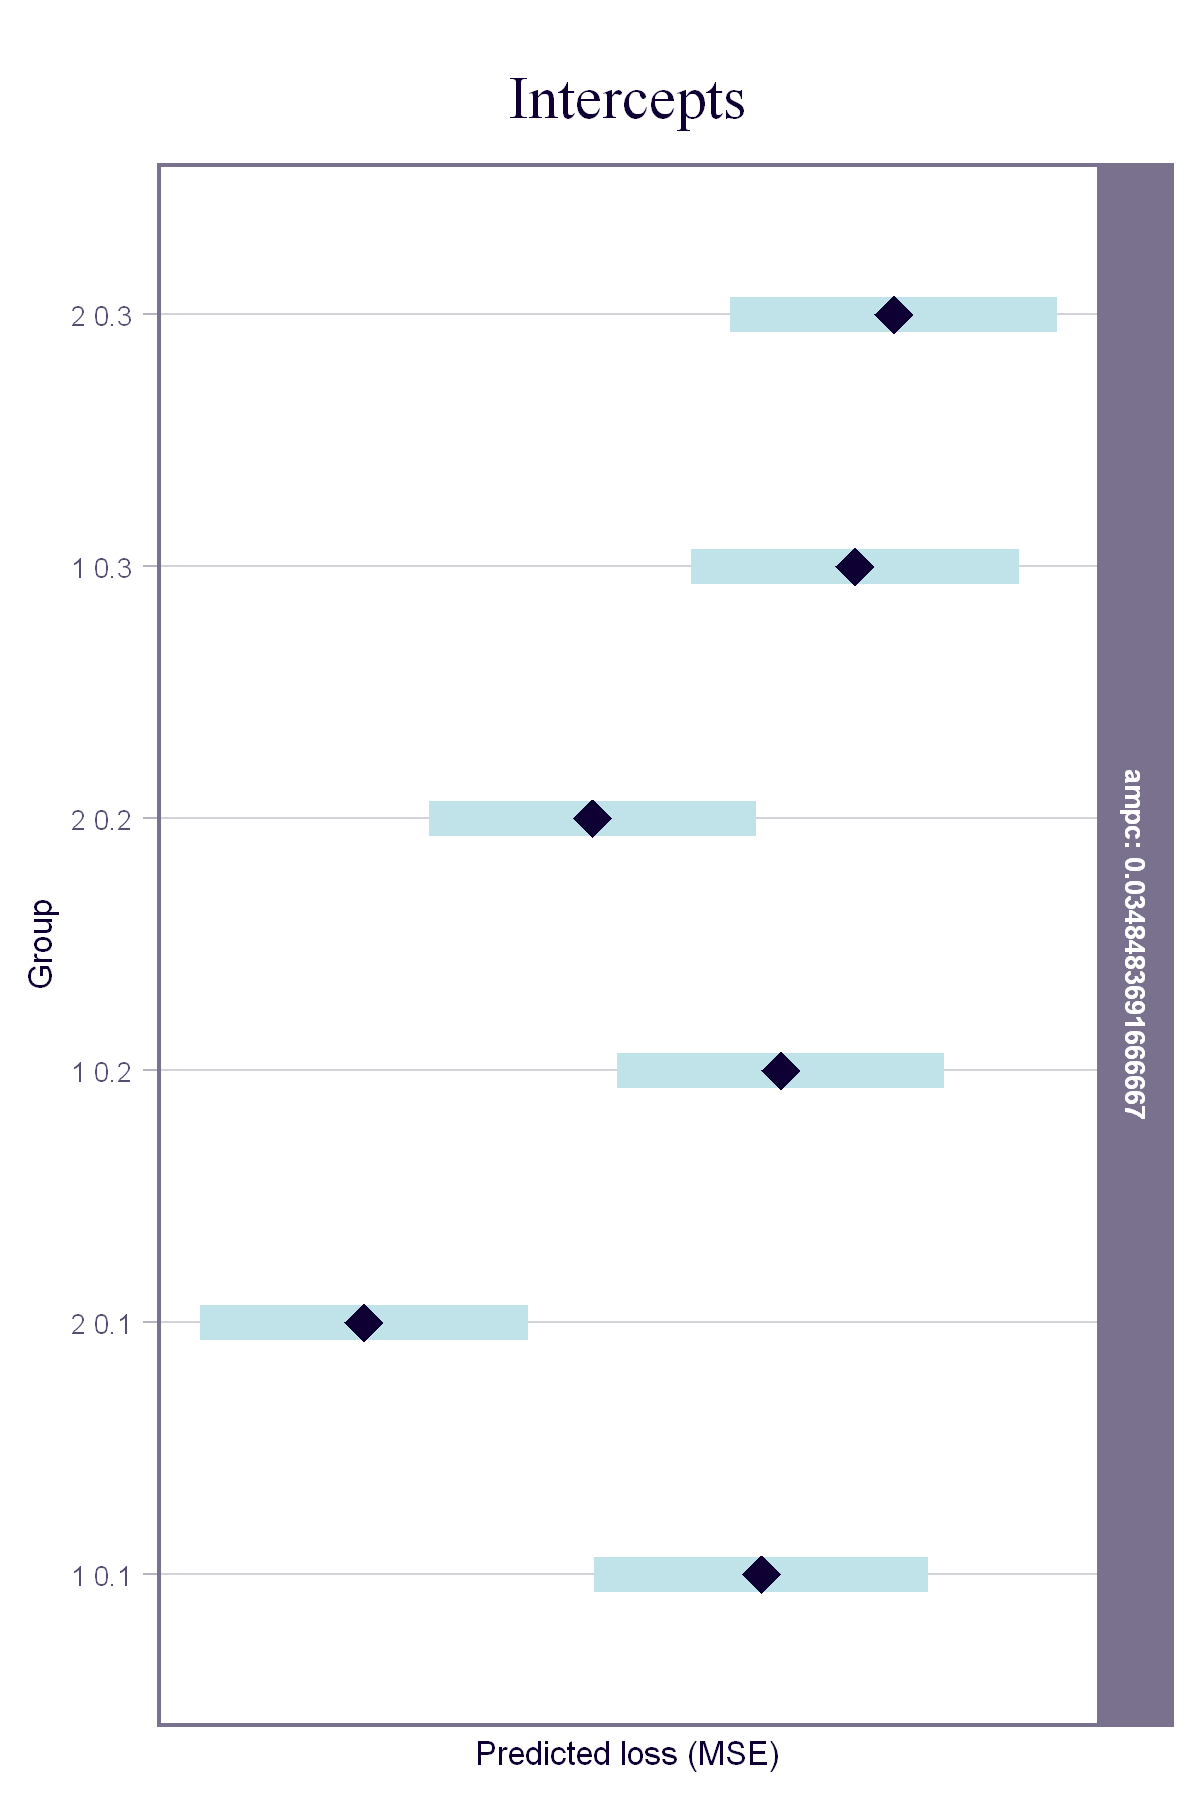

In [10]:
# adjust figure attributes:
options(
    repr.plot.width = 4, 
    repr.plot.height = 6, 
    repr.plot.res = 300
)

emmeans(
    model, 
    pairwise ~ v1_unit+upper_bound|ampc,
    at = list(ampw = c(0.0)) 
)$emmeans %>% plot() +
    labs(
        x = 'Predicted loss (MSE)',
        y = 'Group',
        title = 'Intercepts'
    ) + 
    geom_point(size=0.05) +
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(text = element_text(size = 8)) +
    scale_x_continuous(labels = seq(0,250,10), breaks = seq(0,250,10))

In [11]:
## get the predicted slope for each group

slope_pred = emtrends(
    model, 
    var = 'ampc', 
    specs = c('upper_bound') 
) %>% data.frame()
slope_pred

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

NOTE: Results may be misleading due to involvement in interactions



,upper_bound,ampc.trend,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.1,0.4741331,0.06310946,Inf,0.3504409,0.5978254
2,0.2,0.5398104,0.05681638,Inf,0.4284524,0.6511685
3,0.3,0.4605223,0.05546938,Inf,0.3518043,0.5692403


In [13]:
# ## get the predicted slope for each group

# slope_pred = emtrends(
#     model, 
#     var = 'ampc', 
#     specs = c('upper_bound') 
# ) %>% data.frame()
# slope_pred

# write.csv(slope_pred, 'ampc_slopes_bybounds.csv')

In [14]:
## Get slope contrasts

slope_contrasts = emtrends(
    model, 
    var = 'ampc',
    specs = c('upper_bound') 
)  %>% pairs()  %>% data.frame()
slope_contrasts

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

NOTE: Results may be misleading due to involvement in interactions



,contrast,estimate,SE,df,z.ratio,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,upper_bound0.1 - upper_bound0.2,-0.06567731,0.03644817,Inf,-1.801937,0.1689125515
2,upper_bound0.1 - upper_bound0.3,0.01361083,0.03536154,Inf,0.384905,0.9215899730
3,upper_bound0.2 - upper_bound0.3,0.07928815,0.02099854,Inf,3.775888,0.0004680462


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



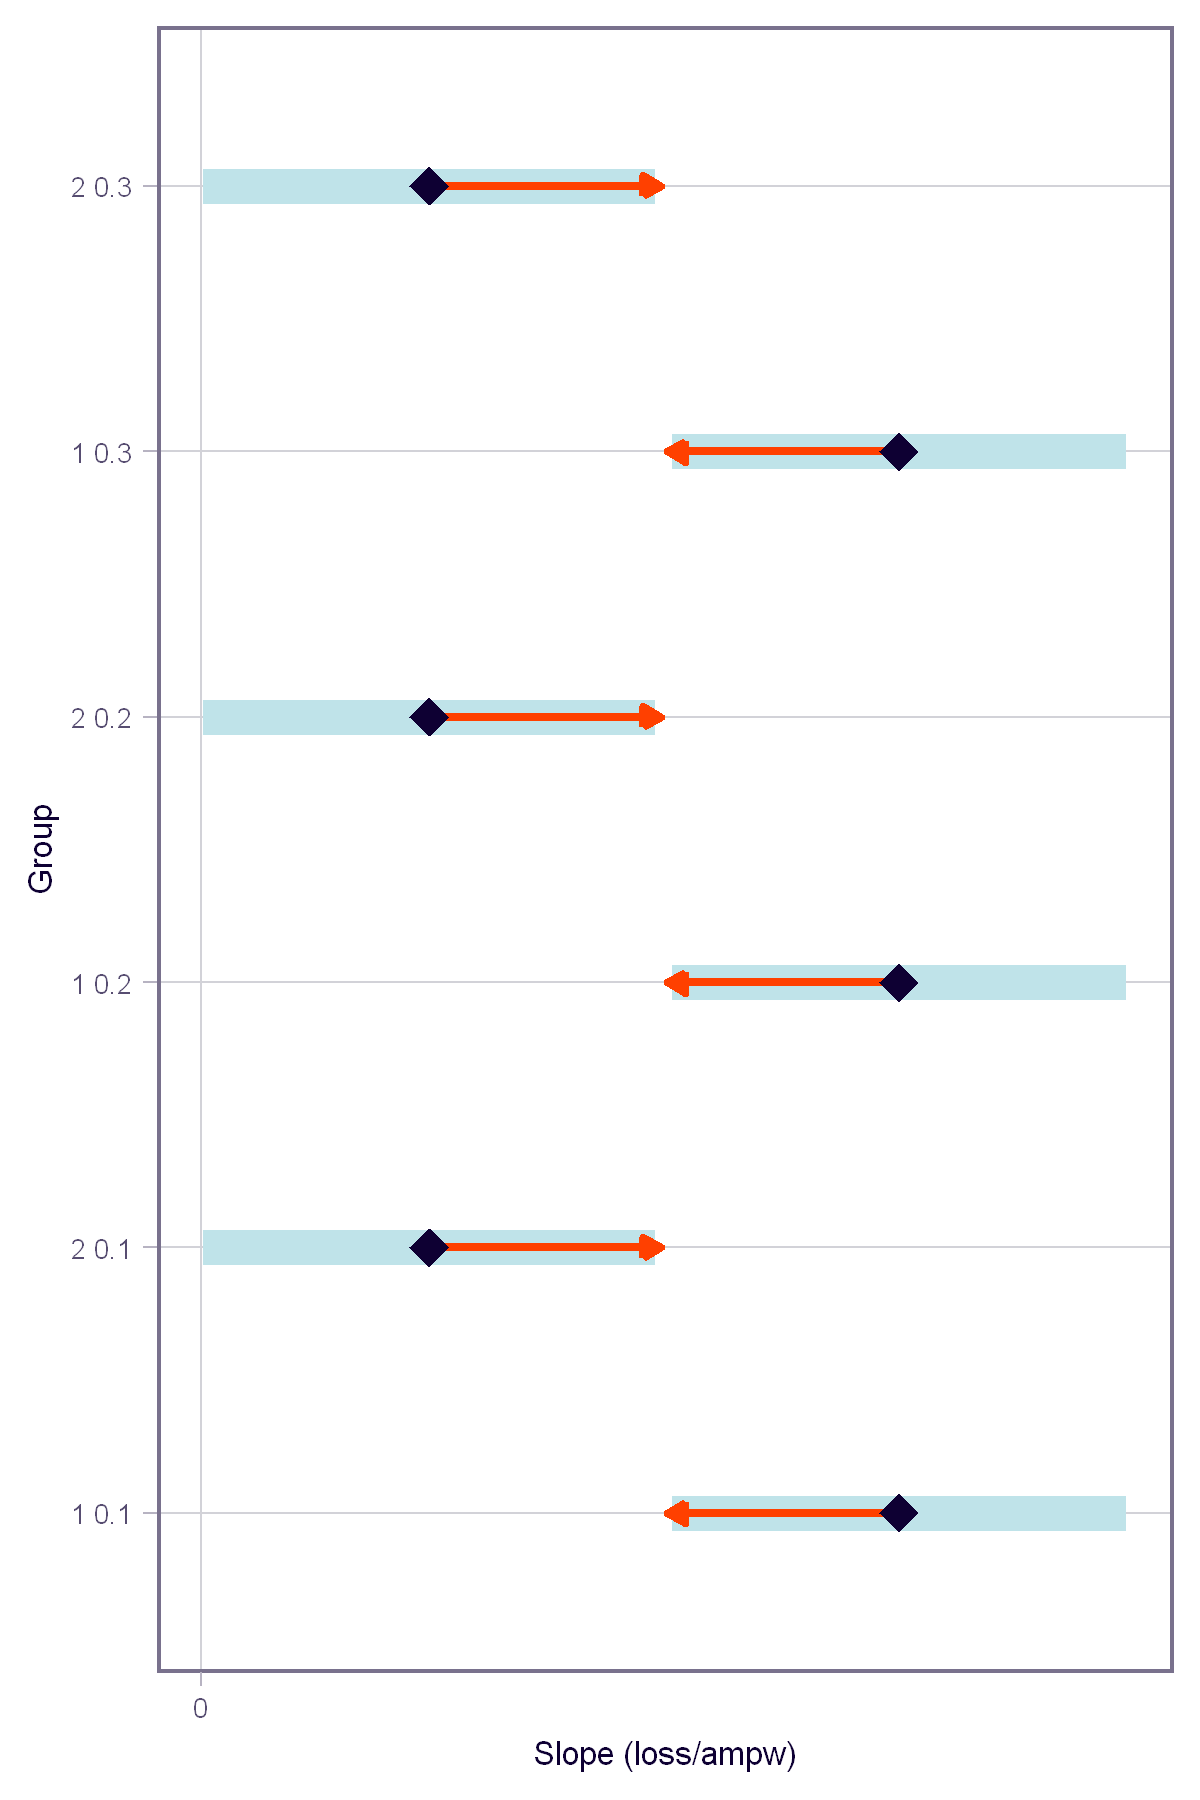

In [ ]:
options(
    repr.plot.width = 4, 
    repr.plot.height = 6, 
    repr.plot.res = 300
)

emtrends(
    model, 
    var = 'ampc', 
    specs = c('v1_unit', 'upper_bound')
) %>% plot(comparisons = TRUE,) +     
    labs(
        x = 'Slope (loss/ampw)',
        y = 'Group',
    ) +
    geom_point(size=0.05)+
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(text = element_text(size = 8)) +
    scale_x_continuous(labels = seq(0,250,10), breaks = seq(0,250,10))

In [ ]:
fixed_effects = as.data.frame(fixef(model))
fixed_effects

,fixef(model)
,<dbl>
(Intercept),0.059919332
ampc,0.973332557
v1_unit,0.007732300
upper_bound0.2,0.006027211
upper_bound0.3,0.015079299
ampc:v1_unit,-0.391695355


In [ ]:
random_effects = as.data.frame(ranef(model, condvar = TRUE))  %>% pivot_wider(
    names_from = term,
    values_from = c(condval, condsd)
)
random_effects

Warning message in ranef.merMod(model, condvar = TRUE):
"additional arguments to ranef.merMod ignored: condvar"


grpvar,grp,condval_(Intercept),condval_ampc,condsd_(Intercept),condsd_ampc
<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
dlgn_unit,1_1,0.006953580,0.009013609,0.0008426358,0.028823993
dlgn_unit,1_2,-0.005523040,0.140637676,0.0008505501,0.023114953
dlgn_unit,1_3,-0.001430539,-0.149651286,0.0007692276,0.020289592
dlgn_unit,2_1,0.002028918,-0.018918001,0.0006571960,0.020625603
dlgn_unit,2_2,-0.004876867,0.188018504,0.0007757678,0.030046371
dlgn_unit,2_3,0.002847949,-0.169100503,0.0003548490,0.004239901


In [ ]:
write.csv(fixed_effects, 'ampc_fixef.csv')
write.csv(random_effects, 'ampc_ranef.csv')
write.csv(intercept_pred, 'ampc_intercepts.csv')
write.csv(slope_pred, 'ampc_slopes.csv')